<a href="https://colab.research.google.com/github/ArjunJSP/ELF_combos/blob/main/collector_design_checks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SETUP:
###Connect to Drive, Import Libraries, Import and crop AISC Section Table

Mount to Drive Location and double check files in the directory


In [93]:
from google.colab import drive
drive.mount('/content/drive')

# Navigate to a specific folder in your Google Drive
%cd /content/drive/My Drive/mountlocation

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/My Drive/mountlocation


Import necessary libraries

In [94]:
import numpy as np
import pandas as pd
from io import StringIO
import re #currently not using
import shlex
import math
import matplotlib.pyplot as plt
import warnings
from openpyxl import load_workbook
from google.colab import data_table
from vega_datasets import data
# pip install XlsxWriter
# import xlsxwriter
# from IPython.core.display import display, HTML

data_table.enable_dataframe_formatter()

Import AISC Section Table

In [95]:
steel_dbs= {'AISC v15.0':
 {'file_path':
  "/content/drive/Shareddrives/Firm-wide Structural Resources/02.General Project Resources/02.06.Spreadsheets/02.06.09 Analysis-Steel/AISC v15 Shapes Database.xlsx",
  'sheet_name': "Database v15.0",
  'US': 'A:CF',
  'Metric': ['A, CG:FJ']}}

STEEL_DB = 'AISC v15.0'
UNITS = 'US'

df_AISC = pd.read_excel(steel_dbs[STEEL_DB]['file_path'],
                         sheet_name=steel_dbs[STEEL_DB]['sheet_name'],
                         usecols=steel_dbs[STEEL_DB][UNITS],
                         header=0)

#Section Properties
df_AISC = df_AISC[['AISC_Manual_Label','A','bf','tf','d','tw','bf/2tf','h/tw','rx','ry']]
#Sections
df_AISC = df_AISC.iloc[66:241, :].dropna().reset_index(drop=True)

# Flexural Buckling Checks (E3)


1.   Define Material Properties
2.   Calculate slenderness based on AISC Table B4.1a
3.   Set $L_c$ = unbraced length
4.   Calculate $F_n$ (E3-2, E3-3)



1. Material Properties

In [96]:
Fy = 50.0 #ksi for gravity members
E = 29000.0 #ksi

2. Slenderness Limits, $λ_r$ for flange and web \\
flange $λ_r$ = $0.56\sqrt{\frac{E}{F_y}}$ \\
web $λ_r$ = $1.49\sqrt{\frac{E}{F_y}}$

In [97]:
flange_slenderness_limit = 0.56*(E/Fy)**0.5
web_slenderness_limit = 1.49*(E/Fy)**0.5
flange_slenderness_limit, web_slenderness_limit

(13.486585928247372, 35.88395184480104)

Unbraced Length, $L_c$ Definition

In [98]:
Lc1 = 32.5 #ft
Lc2 = 38.0 #ft
Lc3 = 31.5/3.0 #ft

4. Calculate $F_n$<br>
if $F_y/F_e≤2.25$,
$F_n = (0.658^{F_y/F_e})F_y$ (E3-2)<br>
if $F_y/F_e > 2.25$,
$F_n = 0.877F_e$<br>
$F_e=\frac{π^2E}{\frac{L_c}{r}^2}$ (E3-3)

In [99]:
#check only for one Lc condition for now
Lc = Lc1*12 #in

Fe_rx = np.pi**2*E/(Lc/df_AISC['rx'])**2 #ksi
Fe_ry = np.pi**2*E/(Lc/df_AISC['ry'])**2 #ksi
Fn_x = np.zeros(len(df_AISC))
Fn_y = np.zeros(len(df_AISC))

def Fn_calculation(Fe, Fy=50):
  #calculate Fn based on a provided Fe
  Fn = np.zeros(len(Fe))
  for i in range(len(Fe)):
    if Fy/Fe[i] <= 2.25:
      Fn[i] = min(0.658**(Fy/Fe[i])*Fy,Fy)
    else:
      Fn[i] = min(0.877*Fe[i], Fy)
  return Fn

Fn_x = Fn_calculation(Fe_rx)
Fn_y = Fn_calculation(Fe_ry)

#Slender Element Checks (E7)
*assuming $L_c$ from above<br>
1.   Calculate $F_el$ for flange and web (based on defined $L_c$)
2.   Calculate $b$, $b_e$ based on slenderness criteria
3.   Calculate $A_e$ of section based on $b_e$, if applicable
4.   Calculate constrained Axis buckling

In [100]:
#Table E7.1 Adjustment Factors
c1_web = 0.18
c1_flange = 0.22
c2_web = 1.31
c2_flange = 1.49

1. Calculate $F_{el} = (c_2\frac{\lambda_r}{\lambda})^2F_y$ (E7-5)

In [101]:
#Fel calculations for flange section and web section
Fel_flange = (c2_flange*flange_slenderness_limit/df_AISC['bf/2tf'])**2*Fy
Fel_web = (c2_web*web_slenderness_limit/df_AISC['h/tw'])**2*Fy

2. Calculate $b$ or $b_e$ <br>
if $\lambda \le \lambda_r \sqrt{\frac{F_y}{F_n}}$, $b_e = b$ (E7-2)<br>
if $\lambda > \lambda_r \sqrt{\frac{F_y}{F_n}}$, $b_e = b(1-c_1\sqrt{\frac{F_{el}}{F_n}})\sqrt{\frac{F_{el}}{F_n}}$ (E7-3) <br>

In [102]:
#b and b_e calculations

def be_calculations(Fel, Fn, slenderness_ratio, slenderness_limit, c1, Fy=50):
  #calculate Fn based on a provided Fe
  b_factor = np.zeros(len(Fn))
  for i in range(len(Fn)):
    if slenderness_ratio[i] <= slenderness_limit*(Fy/Fn[i])**0.5:
      b_factor[i] = 1
    else:
      b_factor[i] = ((1-c1*(Fel[i]/Fn[i]))**0.5)*((Fel[i]/Fn[i])**0.5)
  return b_factor

#be calculations for minor axis flange
be_factor_flange = be_calculations(Fel_flange, Fn_y, df_AISC['bf/2tf'], flange_slenderness_limit, c1_flange, Fy)

#be calculations for minor axis web
be_factor_web = be_calculations(Fel_web, Fn_y, df_AISC['h/tw'], web_slenderness_limit, c1_web, Fy)

3.   Calculate $A_e$ of section based on $b_e$, if applicable

In [103]:
#take gross section area and subtract b*(1-be_factor)
section_area = df_AISC['A'] - (df_AISC['bf']*df_AISC['tf']*(1-be_factor_flange)*2+df_AISC['h/tw']*df_AISC['tw']**2*(1-be_factor_web))

4. Calculate constrained axis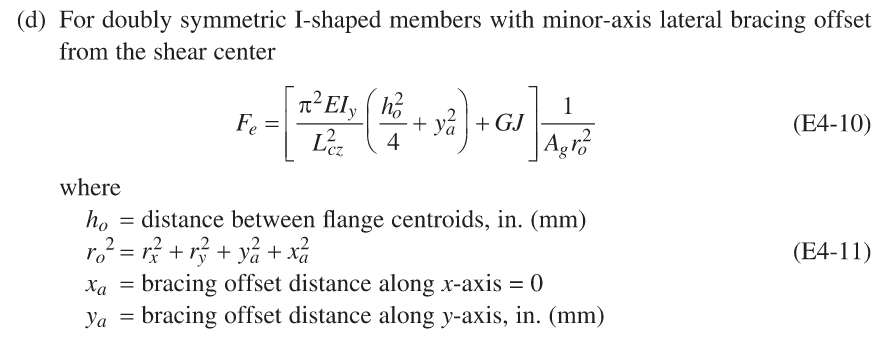